
# Домашнє завдання: Інтеграція Python та SQL: запити даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлены необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно існтрукції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.


In [2]:
import datetime
import requests
import json
import os

from dotenv import load_dotenv
import pandas as pd
import sqlalchemy as sa
from sqlalchemy import create_engine, text, MetaData, Table
from sqlalchemy.orm import sessionmaker


### Завдання 1: Простий запит (1 бал)

Ми працюємо з БД Classicmodels.

**Виведіть інформацію про продукти на складі** з наступними полями:
- назва продукту (productName)
- лінійка продукту (productLine)
- кількість на складі (quantityInStock)
- ціна закупки (buyPrice)

Зчитайте дані з БД з допомогою `pd.read_sql()` з SQLAlchemy engine, який ви створили на етапі підготовки.

Виведіть перші 10 продуктів, відсортованих за кількістю на складі (від більшої кількості до меншої).

In [7]:
query = """
SELECT
    productName,
    productLine,
    quantityInStock,
    buyPrice
FROM products
ORDER BY quantityInStock DESC
LIMIT 10
"""

df_products = pd.read_sql(query, engine)

print("Перші 10 продуктів з найбільшою кількістю на складі:")
display(df_products)

Перші 10 продуктів з найбільшою кількістю на складі:


,productName,productLine,quantityInStock,buyPrice
0,2002 Suzuki XREO,Motorcycles,9997,66.27
1,1995 Honda Civic,Classic Cars,9772,93.89
2,America West Airlines B757-200,Planes,9653,68.80
3,2002 Chevy Corvette,Classic Cars,9446,62.11
4,1932 Model A Ford J-Coupe,Vintage Cars,9354,58.48
5,1982 Ducati 996 R,Motorcycles,9241,24.14
6,1912 Ford Model T Delivery Wagon,Vintage Cars,9173,46.91
7,1976 Ford Gran Torino,Classic Cars,9127,73.49
8,1968 Dodge Charger,Classic Cars,9123,75.16
9,1965 Aston Martin DB5,Classic Cars,9042,65.96



### Завдання 2: Аналітика замовлень за 2004 рік (3 бали)

**Виведіть детальну інформацію про замовлення за 2004 рік** з наступними полями:
- Номер замовлення (orderNumber)
- Дата замовлення (orderDate)
- Статус замовлення (status)
- Ім'я клієнта (customerName)
- Країна клієнта (country)
- Загальна сума замовлення (сума всіх orderdetails.quantityOrdered * orderdetails.priceEach)

Використайте JOIN для об'єднання таблиць orders, customers, orderdetails. Додайте параметризацію за роком (тільки замовлення за 2004 рік).

Використайте `text()` та named parameters для формування запиту з SQLAlchemy.

Після отримання даних з БД проведіть обчислення з Python та напишіть висновки:
1. Побудуйте стовпчасту діаграму суми замовлень по країнам і напишіть, в якій країні найбільша сума замовлень за 2004 рік.
2. В країні з найбільшою кількістю замовлень знайдіть клієнта, який зробив замовлень на найбільшу суму і виведіть імʼя цього клієнта, на яку суму він зробив замовлень і який % від всіх замовлень в цій країні становить його сума замовлень за рік.

In [8]:
from sqlalchemy import text
import pandas as pd

query = text("""
SELECT
    o.orderNumber,
    o.orderDate,
    o.status,
    c.customerName,
    c.country,
    SUM(od.quantityOrdered * od.priceEach) AS orderTotal
FROM orders o
JOIN customers c 
    ON o.customerNumber = c.customerNumber
JOIN orderdetails od 
    ON o.orderNumber = od.orderNumber
WHERE YEAR(o.orderDate) = :year
GROUP BY 
    o.orderNumber,
    o.orderDate,
    o.status,
    c.customerName,
    c.country
ORDER BY orderTotal DESC
""")

df_orders = pd.read_sql(query, engine, params={"year": 2004})

df_orders.head()

,orderNumber,orderDate,status,customerName,country,orderTotal
0,10287,2004-08-30,Shipped,"Vida Sport, Ltd",Switzerland,61402.00
1,10310,2004-10-16,Shipped,"Toms Spezialitäten, Ltd",Germany,61234.67
2,10212,2004-01-16,Shipped,Euro+ Shopping Channel,Spain,59830.55
3,10222,2004-02-19,Shipped,Collectable Mini Designs Co.,USA,56822.65
4,10312,2004-10-21,Shipped,Mini Gifts Distributors Ltd.,USA,55639.66


1. Побудуйте стовпчасту діаграму суми замовлень по країнам і напишіть, в якій країні найбільша сума замовлень за 2004 рік.

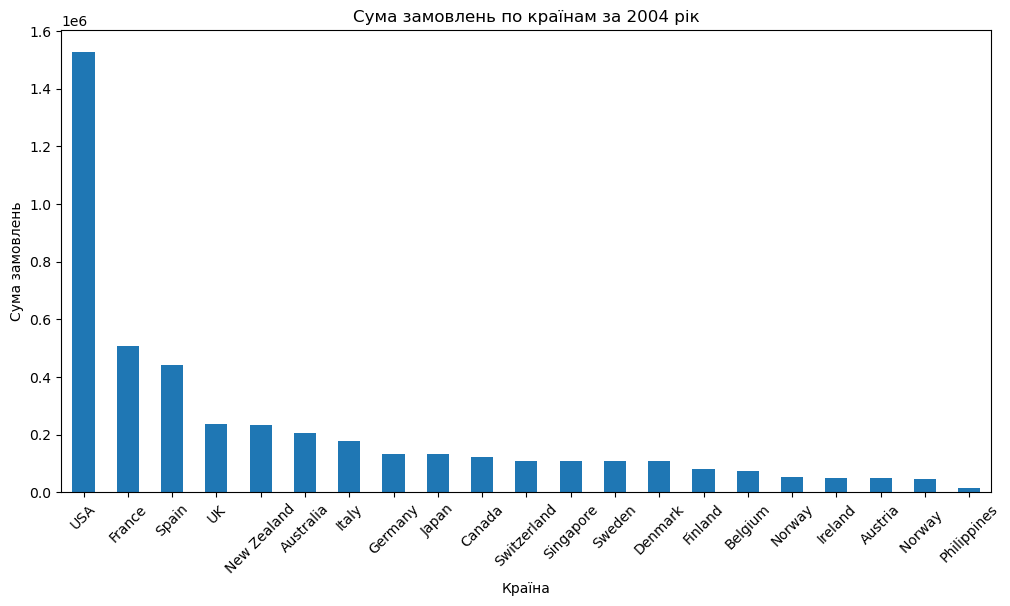

In [12]:
country_sales = (
    df_orders
    .groupby("country")["orderTotal"]
    .sum()
    .sort_values(ascending=False)
)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
country_sales.plot(kind="bar")

plt.title("Сума замовлень по країнам за 2004 рік")
plt.xlabel("Країна")
plt.ylabel("Сума замовлень")
plt.xticks(rotation=45)

plt.show()

Найбільше замовлень у USA

2. В країні з найбільшою кількістю замовлень знайдіть клієнта, який зробив замовлень на найбільшу суму і виведіть імʼя цього клієнта, на яку суму він зробив замовлень і який % від всіх замовлень в цій країні становить його сума замовлень за рік.

In [15]:
top_country = country_sales.idxmax()
top_country
country_customers = df_orders[df_orders["country"] == top_country]

customer_sales = (
    country_customers
    .groupby("customerName")["orderTotal"]
    .sum()
    .sort_values(ascending=False)
)
customer_sales.head()

top_customer = customer_sales.idxmax()
top_customer_sales = customer_sales.max()
country_total_sales = customer_sales.sum()
percentage = (top_customer_sales / country_total_sales) * 100

print("Країна з найбільшою кількістю замовлень:", top_country)
print("Клієнт з найбільшою сумою:", top_customer)
print("Сума його замовлень:", round(top_customer_sales,2))
print("% від замовлень країни:", round(percentage,2), "%")

Країна з найбільшою кількістю замовлень: USA
Клієнт з найбільшою сумою: Mini Gifts Distributors Ltd.
Сума його замовлень: 231562.53
% від замовлень країни: 15.17 %



### Завдання 3: Аналітичний запит - Топ продуктів по продажах (6 балів)

В цьому завданні ви отримуєте 1 бал за правильний SQL запит і по 1 балу за кожне завдання з Python.

**Проведіть аналіз прибутковості продуктів** та для цього дістаньте з БД інформацію з наступними полями:
- Назва продукту
- Лінійка продукту (productLine)
- Загальний дохід з цього продукту (сума quantity * priceEach)
- Ранг продукту по доходу (тобто яке місце посідає цей продукт за доходом серед усіх продуктів в нашому магазині)
- Який відсоток від загального доходу компанії складає цей продукт
- Різниця з середнім доходом по лінійці продукту (в %)

Відсортуйте дані за спаданням значень колонки "Який відсоток від загального доходу компанії складає цей продукт".

При створенні SQL запиту вам можуть стати в нагоді:
- **CTE** для розрахунку доходу по кожному продукту
- **Віконні функції** для ранжування та порівняння з середнім

Після отримання даних з БД проведіть обчислення (де треба) з Python та напишіть висновки:
1. Який відсоток від загального доходу складає ТОП1 продукт і що це за продукт?
2. Створіть стовпчикову діаграму топ-10 продуктів по доходу. В скільки разів відрізняється сумарний дохід за ТОП1 продуктом від 10го продукту за сумою доходу?
3. Створіть кругову діаграму розподілу доходу по лініях продуктів. Який відсоток від всіх продажів становлять продажі за ТОП2 лініями сумарно?
4. Розрахуйте та виведіть за принципом Парето (80/20) - скільки продуктів дають 80% доходу. Тобто нам треба знайти кількість продуктів сумарне значення "відсотку від загального доходу компанії", яких складає 80 починаючи з продукту з найбільшим цим відсотком.
5. Зробіть ще будь-яке аналітичне дослідження, яке дасть нам більше розуміння наших даних, що ми дістали в БД в цьому завданні. Сформоване питання до даних і обчислення має бути обовʼязково. Візуалізація - опціонально.

Візуалізацію можна створювати з будь-якою бібліотекою на ваш вибір.

In [16]:
from sqlalchemy import text
import pandas as pd

query = text("""

WITH product_revenue AS (
    SELECT
        p.productName,
        p.productLine,
        SUM(od.quantityOrdered * od.priceEach) AS revenue
    FROM products p
    JOIN orderdetails od
        ON p.productCode = od.productCode
    GROUP BY p.productName, p.productLine
),

total_revenue AS (
    SELECT SUM(revenue) AS total_rev
    FROM product_revenue
)

SELECT
    pr.productName,
    pr.productLine,
    pr.revenue,

    RANK() OVER (ORDER BY pr.revenue DESC) AS revenue_rank,

    pr.revenue / tr.total_rev * 100 AS revenue_percent,

    (pr.revenue - AVG(pr.revenue) OVER(PARTITION BY pr.productLine)) /
    AVG(pr.revenue) OVER(PARTITION BY pr.productLine) * 100
    AS diff_from_line_avg_pct

FROM product_revenue pr
CROSS JOIN total_revenue tr

ORDER BY revenue_percent DESC

""")

df_products = pd.read_sql(query, engine)

df_products.head()

,productName,productLine,revenue,revenue_rank,revenue_percent,diff_from_line_avg_pct
0,1992 Ferrari 360 Spider red,Classic Cars,276839.98,1,2.8825,165.783219
1,2001 Ferrari Enzo,Classic Cars,190755.86,2,1.9862,83.137228
2,1952 Alpine Renault 1300,Classic Cars,190017.96,3,1.9785,82.428799
3,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,170686.00,4,1.7772,97.865732
4,1968 Ford Mustang,Classic Cars,161531.48,5,1.6819,55.080046


1. Який відсоток від загального доходу складає ТОП1 продукт і що це за продукт?

In [18]:
top_product = df_products.iloc[0]

print("ТОП1 продукт:", top_product["productName"])
print("Відсоток від загального доходу:", round(top_product["revenue_percent"],2), "%")

ТОП1 продукт: 1992 Ferrari 360 Spider red
Відсоток від загального доходу: 2.88 %


2. Створіть стовпчикову діаграму топ-10 продуктів по доходу. В скільки разів відрізняється сумарний дохід за ТОП1 продуктом від 10го продукту за сумою доходу?

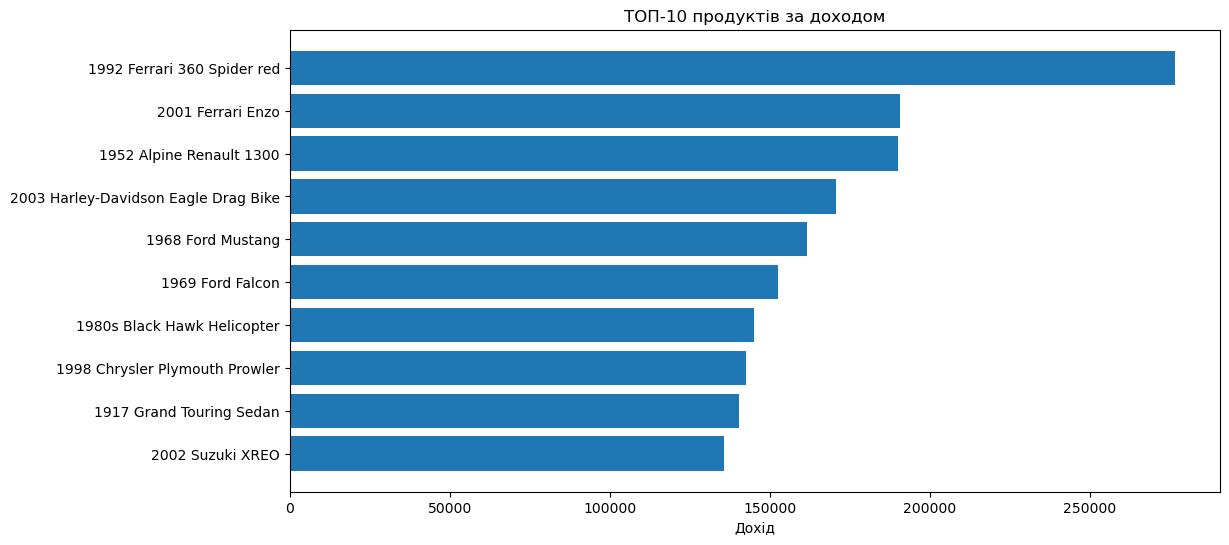

Сумарний дохід за ТОП1 відрізняється у 2.04 разів від 10-го продукту


In [25]:
top10 = df_products.head(10)

plt.figure(figsize=(12,6))
plt.barh(top10["productName"], top10["revenue"])
plt.title("ТОП-10 продуктів за доходом")
plt.xlabel("Дохід")
plt.gca().invert_yaxis()
plt.show()

top1_revenue = top10.iloc[0]["revenue"]
top10_revenue = top10.iloc[-1]["revenue"]
ratio = top1_revenue / top10_revenue
print("Сумарний дохід за ТОП1 відрізняється у", round(ratio,2), "разів від 10-го продукту")

3. Створіть кругову діаграму розподілу доходу по лініях продуктів. Який відсоток від всіх продажів становлять продажі за ТОП2 лініями сумарно?

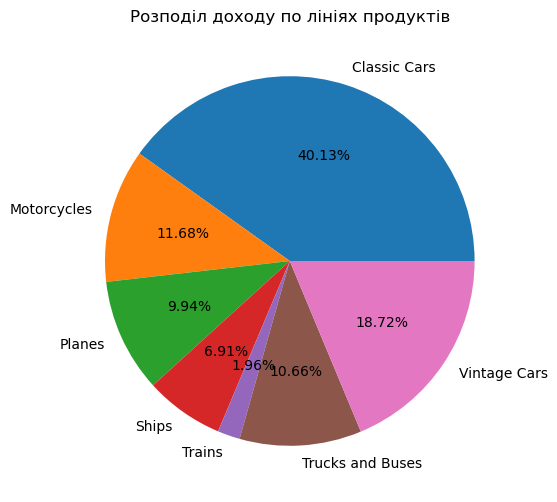

ТОП2 лінії продуктів сумарно ставновлять: 58.84 % продажів


In [32]:
line_revenue = df_products.groupby("productLine")["revenue"].sum()
plt.figure(figsize=(6,6))
plt.pie(
    line_revenue,
    labels=line_revenue.index,
    autopct='%1.2f%%'
)
plt.title("Розподіл доходу по лініях продуктів")
plt.show()

top2_lines = line_revenue.sort_values(ascending=False).head(2)
top2_percent = top2_lines.sum() / line_revenue.sum() * 100
print("ТОП2 лінії продуктів сумарно ставновлять:", round(top2_percent,2), "% продажів")

4. Розрахуйте та виведіть за принципом Парето (80/20) - скільки продуктів дають 80% доходу. Тобто нам треба знайти кількість продуктів сумарне значення "відсотку від загального доходу компанії", яких складає 80 починаючи з продукту з найбільшим цим відсотком.

In [33]:
df_products["cum_percent"] = df_products["revenue_percent"].cumsum()
pareto_products = df_products[df_products["cum_percent"] <= 80]
print("Кількість продуктів що дають 80% доходу:", len(pareto_products))

Кількість продуктів що дають 80% доходу: 71


5. Зробіть ще будь-яке аналітичне дослідження, яке дасть нам більше розуміння наших даних, що ми дістали в БД в цьому завданні. Сформоване питання до даних і обчислення має бути обовʼязково. Візуалізація - опціонально.

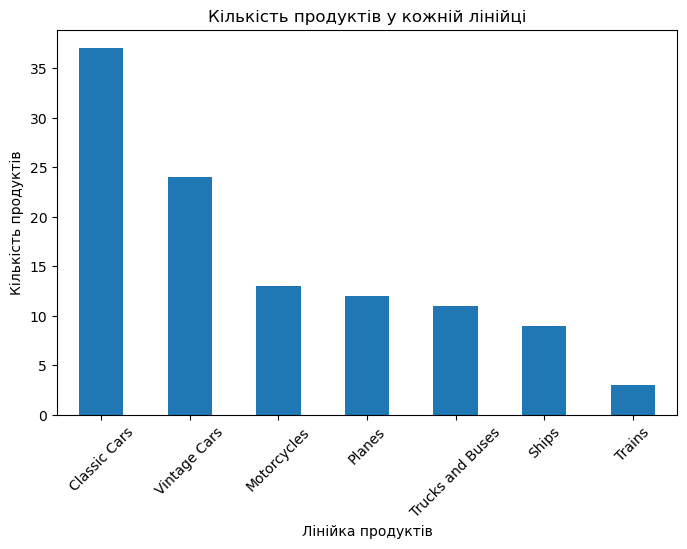

In [34]:
products_per_line = (
    df_products
    .groupby("productLine")["productName"]
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
products_per_line.plot(kind="bar")
plt.title("Кількість продуктів у кожній лінійці")
plt.xlabel("Лінійка продуктів")
plt.ylabel("Кількість продуктів")
plt.xticks(rotation=45)
plt.show()

Найбільшу кількість продуктів мають лінійки Classic Cars та Vintage Cars, що свідчить про те, що компанія найбільше зацікавлена в автомобільній галузі. Інші лінійки мають меншу кількість продуктів, що може означати менший попит або ці продукти не основний напрямок діяльності компанії.

### ОПЦІОНАЛЬНО. Завдання 4: Аналітичний запит - Динаміка продажів по місяцях (8 балів)

**Проведіть аналіз динаміки продажів по місяцях** та для цього дістаньте з бази інформацію з наступними полями:
- Рік та місяць замовлень
- Кількість замовлень за цей рік-місяць
- Загальний дохід (quantityOrdered * priceEach) за цей рік-місяць
- На який % ми зросли за доходом порівняно з попереднім місяцем
- Накопичувальний дохід до цього місяця за рік
- Ковзне середнє доходу за 3 місяці
- Ранг цього місяця за доходом

Використайте:
- **CTE** для агрегації продажів по місяцях
- **Віконні функції** для розрахунку:
  - Зростання доходу порівняно з попереднім місяцем (LAG)
  - Накопичувальний дохід за рік
  - Ковзне середнє доходу за 3 місяці (AVG OVER)
  - Ранжування місяців за доходом (RANK)

Після отримання даних з БД побудуйте наступні графіки і напишіть коротко, які висновки з них можна зробити.
1. Створіть лінійний графік доходу по місяцях. Чи є тред до зростання в даних?
2. Створіть графік місяць-до-місяця зростання у відсотках.
3. Створіть heatmap сезонності (місяць vs рік)
4. Відобразіть козвне середнє разом з динамікою продажів.
5. Розрахуйте кореляцію між кількістю замовлень та середнім чеком та побудуйте графік розсіювання між цими змінними. Чи є лінійна залежність?

Очікуваний результат кожного графіку - нижче.
В першому графіку я додала лінію тренду аби показати тренд. Вам її додавати не треба.


In [37]:
from sqlalchemy import text
import pandas as pd

query = text("""

WITH monthly_sales AS (
    SELECT
        YEAR(o.orderDate) AS year,
        MONTH(o.orderDate) AS month,
        COUNT(DISTINCT o.orderNumber) AS orders_count,
        SUM(od.quantityOrdered * od.priceEach) AS revenue
    FROM orders o
    JOIN orderdetails od 
        ON o.orderNumber = od.orderNumber
    GROUP BY YEAR(o.orderDate), MONTH(o.orderDate)
)

SELECT
    year,
    month,
    orders_count,
    revenue,

    LAG(revenue) OVER (ORDER BY year, month) AS prev_month_revenue,

    (revenue - LAG(revenue) OVER (ORDER BY year, month)) /
    LAG(revenue) OVER (ORDER BY year, month) * 100 AS revenue_growth_pct,

    SUM(revenue) OVER (
        PARTITION BY year 
        ORDER BY month
    ) AS cumulative_revenue,

    AVG(revenue) OVER (
        ORDER BY year, month
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS moving_avg_3m,

    RANK() OVER (
        ORDER BY revenue DESC
    ) AS revenue_rank

FROM monthly_sales
ORDER BY year, month

""")

df_sales = pd.read_sql(query, engine)
df_sales.head()

,year,month,orders_count,revenue,prev_month_revenue,revenue_growth_pct,cumulative_revenue,moving_avg_3m,revenue_rank
0,2003,1,5,116692.77,NaN,NaN,116692.77,116692.770000,29
1,2003,2,3,128403.64,116692.77,10.0356,245096.41,122548.205000,28
2,2003,3,6,160517.14,128403.64,25.0098,405613.55,135204.516667,26
3,2003,4,7,185848.59,160517.14,15.7811,591462.14,158256.456667,23
4,2003,5,6,179435.55,185848.59,-3.4507,770897.69,175267.093333,24


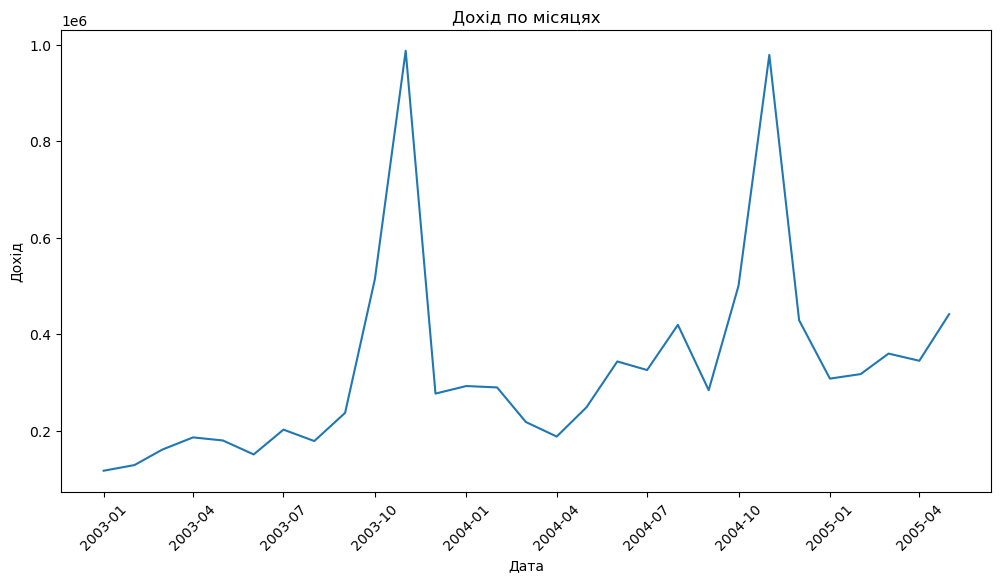

In [44]:
# 1. Лінійний графік доходу без тренду
df_sales["date"] = pd.to_datetime(
    df_sales["year"].astype(str) + "-" + df_sales["month"].astype(str)
)

plt.figure(figsize=(12,6))
plt.plot(df_sales["date"], df_sales["revenue"])
plt.title("Дохід по місяцях")
plt.xlabel("Дата")
plt.xticks(rotation=45)
plt.ylabel("Дохід")
plt.show()

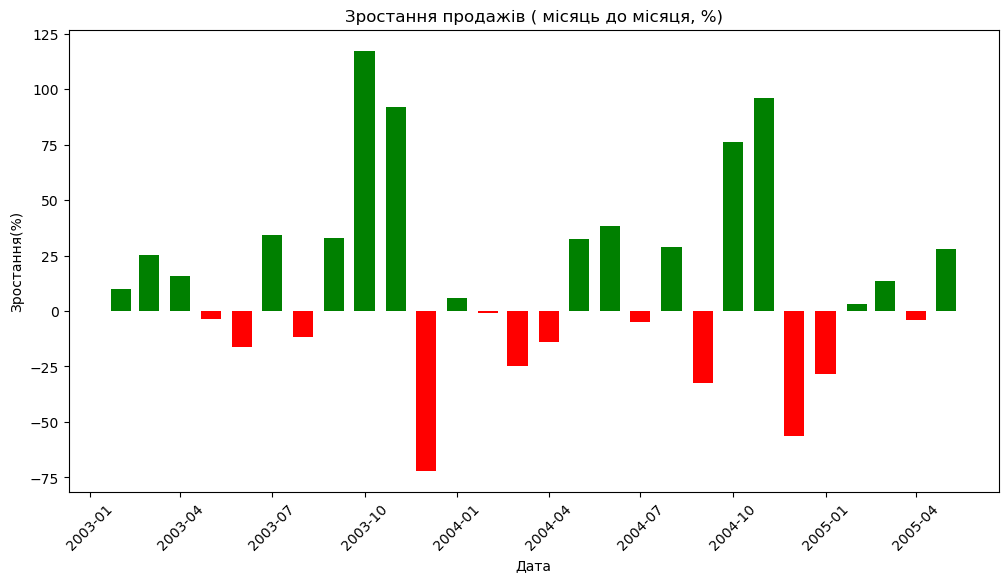

In [48]:
# 2. Місяць-до-місяця зростання
plt.figure(figsize=(12,6))
colors = df_sales["revenue_growth_pct"].apply(lambda x: "green" if x >= 0 else "red")
plt.bar( df_sales["date"], df_sales["revenue_growth_pct"], color=colors, width=20)
plt.title("Зростання продажів ( місяць до місяця, %)")
plt.xlabel("Дата")
plt.xticks(rotation=45)
plt.ylabel("Зростання(%)")
plt.show()

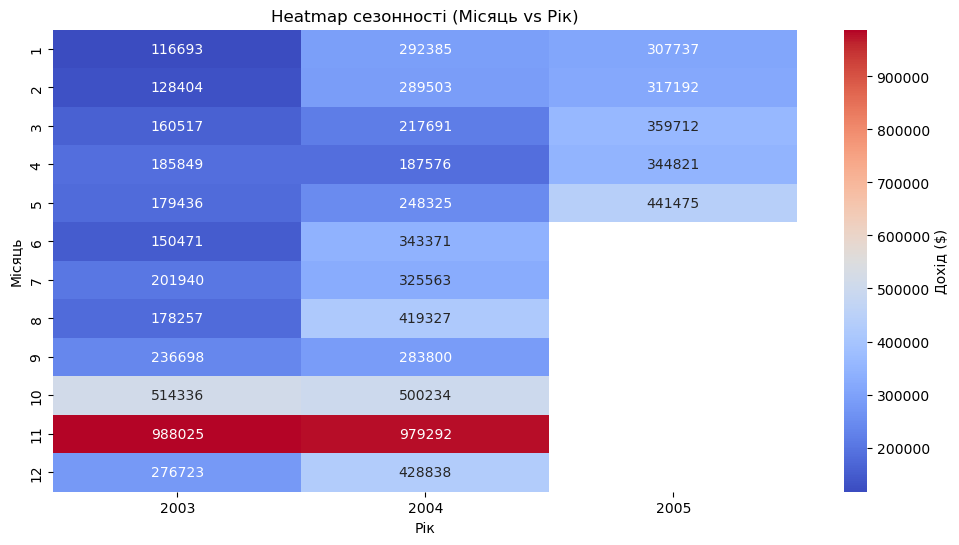

In [52]:
# 3. Heatmap сезонності
import seaborn as sns
pivot = df_sales.pivot( index="month", columns="year", values="revenue")
plt.figure(figsize=(12,6))
sns.heatmap( pivot, annot=True, fmt=".0f", cmap="coolwarm", cbar_kws={"label": "Дохід ($)"})
plt.xlabel("Рік")
plt.ylabel("Місяць")
plt.title("Heatmap сезонності (Місяць vs Рік)")
plt.show()

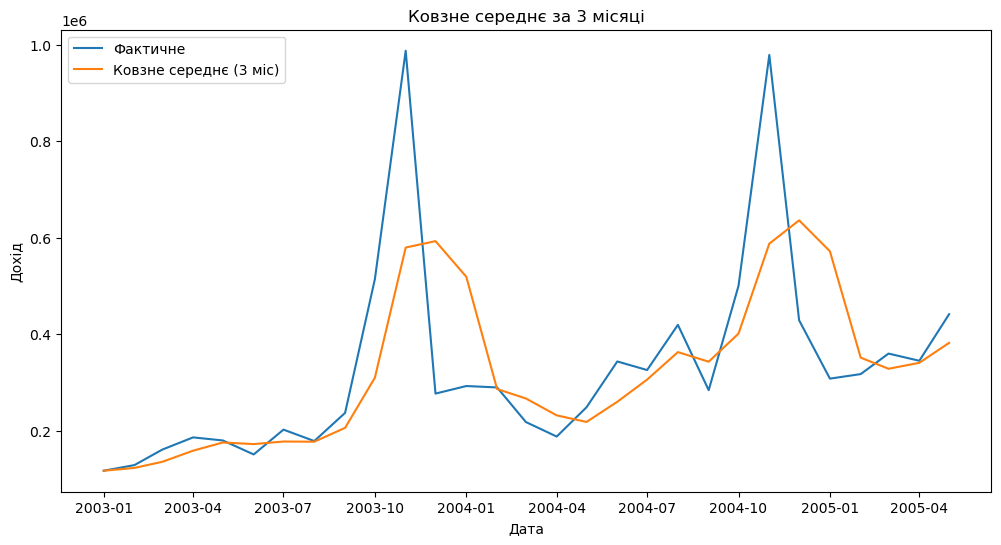

In [54]:
# 4. Ковзне середнє з динімікою доходу
plt.figure(figsize=(12,6))
plt.plot(df_sales["date"], df_sales["revenue"], label="Фактичне")
plt.plot(df_sales["date"], df_sales["moving_avg_3m"], label="Ковзне середнє (3 міс)")
plt.legend()
plt.title("Ковзне середнє за 3 місяці")
plt.xlabel("Дата")
plt.ylabel("Дохід")
plt.show()

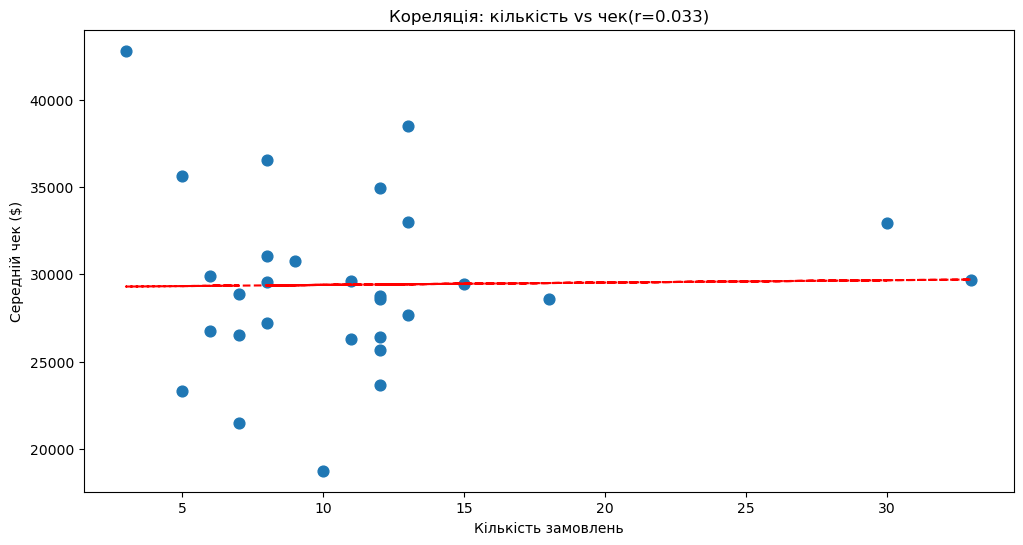

In [57]:
# 5. Кореляція замовлень та середнього чеку
import numpy as np
x = df_sales["orders_count"]
y = df_sales["avg_check"]
с = np.corrcoef(x, y)[0,1]
m, b = np.polyfit(x, y, 1)
y_fit = m*x + b

plt.figure(figsize=(12,6))
plt.scatter(x, y, s=60)  
plt.plot(x, y_fit, color="red", linestyle="--") 
plt.title("Кореляція: кількість vs чек(r=0.033)")
plt.xlabel("Кількість замовлень")
plt.ylabel("Середній чек ($)")
plt.show()

Є аутлаєри, але в загальному не можна сказати, що кореляція присутня.